In [8]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
boot_lap_pvals = np.genfromtxt('Computed_pvals2_boot_laplace.txt')
boot_gennorm_pvals = np.genfromtxt('Computed_pvals2_boot_gennorm.txt')
boot_gaussian_pvals = np.genfromtxt('Computed_pvals2_boot_gaussian.txt')
boot_student_pvals = np.genfromtxt('Computed_pvals2_boot_st.txt')
boot_hyper_pvals = np.genfromtxt('Computed_pvals2_boot_hs.txt')

lmr_lap_pvals = np.genfromtxt('Computed_pvals2_lmr_laplace.txt')
lmr_gennorm_pvals = np.genfromtxt('Computed_pvals2_lmr_gn.txt')
lmr_gaussian_pvals = np.genfromtxt('Computed_pvals2_lmr_gaussian.txt')
lmr_student_pvals = np.genfromtxt('Computed_pvals2_lmr_st.txt')
lmr_hyper_pvals = np.genfromtxt('Computed_pvals2_lmr_hs.txt')

In [13]:
# Common styling helper
def stylize_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.tick_params(width=1.2, length=4)
    ax.title.set_fontsize(20)
    ax.xaxis.label.set_fontsize(16)
    ax.yaxis.label.set_fontsize(16)

def fit_beta_a1_posterior(p_values, alpha_prior=1.0, lambda_prior=1.0):
    """
    Fit Beta(a, 1) model with Gamma(alpha, lambda) prior on 'a'.
    Posterior: Gamma(alpha + n, lambda - sum(log(p)))
    """
    n = len(p_values)
    sum_log_p = np.sum(np.log(p_values))
    alpha_post = alpha_prior + n
    lambda_post = lambda_prior - sum_log_p
    
    a_mean = alpha_post / lambda_post
    a_lower = stats.gamma.ppf(0.025, alpha_post, scale=1/lambda_post)
    a_upper = stats.gamma.ppf(0.975, alpha_post, scale=1/lambda_post)
    
    return a_mean, a_lower, a_upper

def clopper_pearson_upper(k, n, alpha=0.05):
    """Upper bound of Clopper-Pearson confidence interval."""
    if k == n:
        return 1.0
    return stats.beta.ppf(1 - alpha/2, k + 1, n - k)


    
def plotFig(p_values,sname):
    # Fit model
    a_est, a_lower, a_upper = fit_beta_a1_posterior(p_values)
    n_below_05 = np.sum(p_values < 0.05)
    cp_upper = clopper_pearson_upper(n_below_05, len(p_values))

    print(f"Beta(a, 1) posterior: a = {a_est:.3f} (95% CI: [{a_lower:.3f}, {a_upper:.3f}])")
    print(f"Conservative (a > 1): {a_lower > 1}")
    print(f"Type I error at α=0.05: {n_below_05}/{len(p_values)} = {n_below_05/len(p_values):.3f}")
    print(f"Clopper-Pearson 97.5% upper bound: {cp_upper:.3f}")
    
    # Figure setup
    fig, axes = plt.subplots(1, 2, figsize=(7, 3.2))

    color_hist = '#88AADD'     # softer blue
    color_uniform = '#666666'  # dark gray
    color_beta = '#E07B91'     # muted pink
    color_ci = '#CCCCCC'       # light gray

    ax = axes[0]
    ax.hist(p_values, bins=15, density=True, alpha=0.7, color=color_hist,
        edgecolor='white', linewidth=0.8, label='Observed')

    ax.axhline(y=1, color=color_uniform, linestyle='--', linewidth=1.5,
           label=r'Uniform$(0,1)$')

    x_dense = np.linspace(0.001, 0.999, 500)
    ax.plot(x_dense, stats.beta.pdf(x_dense, a_est, 1), color=color_beta,
        linewidth=2, label=fr'Beta$(\hat{{a}}, 1)$, $\hat{{a}}={a_est:.2f}$')

    ax.fill_between(x_dense, stats.beta.pdf(x_dense, a_lower, 1),
                stats.beta.pdf(x_dense, a_upper, 1),
                color=color_beta, alpha=0.15, label='95% CI')

    ax.axvline(x=0.05, color='gray', linestyle=':', linewidth=1, alpha=0.8)
    ax.text(0.07, ax.get_ylim()[1]*0.9, r'$\alpha=0.05$', fontsize=9, color='gray')

    ax.set_xlabel(r'$p$-value',fontsize=20)
    ax.set_ylabel('Density',fontsize=20)
    ax.set_xlim(0, 1)
    ax.legend(loc='upper right', frameon=False)
    ax.set_title('P-value distribution', fontsize=28)
    stylize_axes(ax)

    ax = axes[1]
    p_sorted = np.sort(p_values)
    n = len(p_values)
    theoretical_quantiles = (np.arange(1, n + 1) - 0.5) / n

    ci_lower = stats.beta.ppf(0.025, np.arange(1, n + 1), n - np.arange(1, n + 1) + 1)
    ci_upper = stats.beta.ppf(0.975, np.arange(1, n + 1), n - np.arange(1, n + 1) + 1)

    #ax.fill_between(theoretical_quantiles, ci_lower, ci_upper,
    #            color=color_ci, alpha=0.4, label='95% CI')

    ax.plot([0, 1], [0, 1], color=color_uniform, linestyle='--', linewidth=1.5)

    ax.scatter(theoretical_quantiles, p_sorted, s=16, color=color_hist,
           alpha=0.7, edgecolors='none', label='Observed')

    ax.plot(theoretical_quantiles, stats.beta.ppf(theoretical_quantiles, a_est, 1),
        color=color_beta, linewidth=1.5, label=fr'Beta$({a_est:.2f}, 1)$')

    ax.set_xlabel('Theoretical quantiles ',fontsize=20)
    ax.set_ylabel('Observed quantiles',fontsize=20)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper left', frameon=False)
    ax.set_title('Q-Q Plot',fontsize=36)
    stylize_axes(ax)

    # Layout
    plt.tight_layout()
    plt.savefig(sname)
    plt.show()


Beta(a, 1) posterior: a = 0.761 (95% CI: [0.715, 0.809])
Conservative (a > 1): False
Type I error at α=0.05: 92/1000 = 0.092
Clopper-Pearson 97.5% upper bound: 0.112


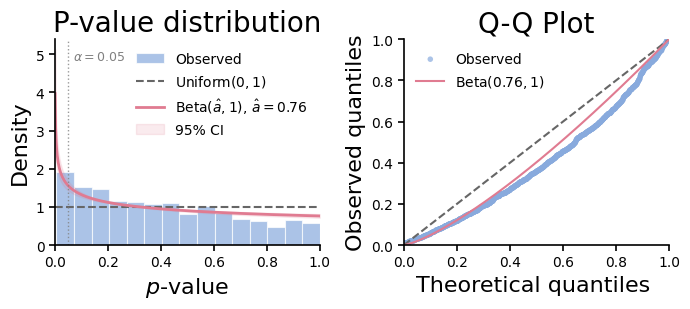

In [14]:
plotFig(boot_lap_pvals,'Laplace_boot.pdf')

Beta(a, 1) posterior: a = 0.954 (95% CI: [0.896, 1.014])
Conservative (a > 1): False
Type I error at α=0.05: 49/1000 = 0.049
Clopper-Pearson 97.5% upper bound: 0.064


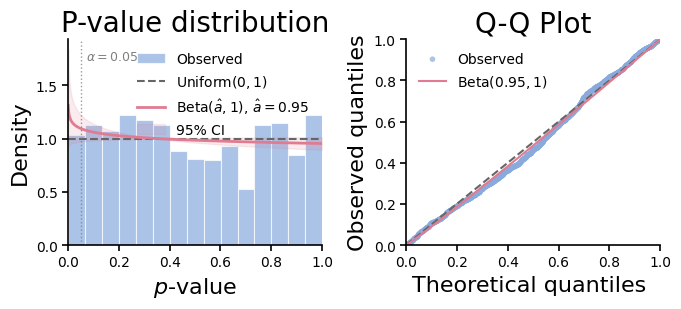

In [16]:
plotFig(boot_gaussian_pvals,'Gauss_boot.pdf')

Beta(a, 1) posterior: a = 0.939 (95% CI: [0.882, 0.999])
Conservative (a > 1): False
Type I error at α=0.05: 41/1000 = 0.041
Clopper-Pearson 97.5% upper bound: 0.055


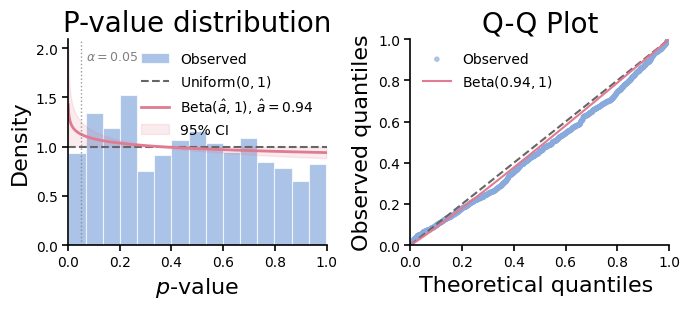

In [18]:
plotFig(boot_gennorm_pvals,'Gennorm_boot.pdf')

Beta(a, 1) posterior: a = 1.031 (95% CI: [0.968, 1.096])
Conservative (a > 1): False
Type I error at α=0.05: 19/1000 = 0.019
Clopper-Pearson 97.5% upper bound: 0.030


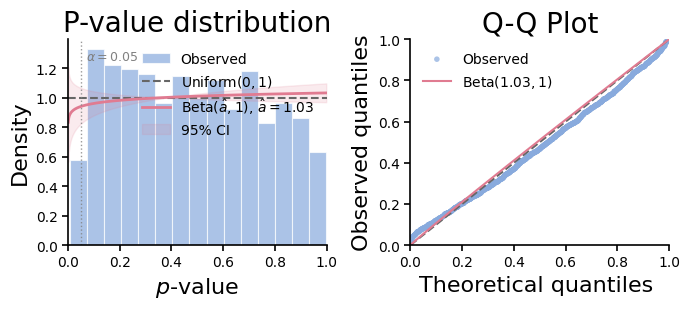

In [19]:
plotFig(boot_student_pvals,'Student_boot.pdf')

Beta(a, 1) posterior: a = 0.912 (95% CI: [0.856, 0.969])
Conservative (a > 1): False
Type I error at α=0.05: 46/1000 = 0.046
Clopper-Pearson 97.5% upper bound: 0.061


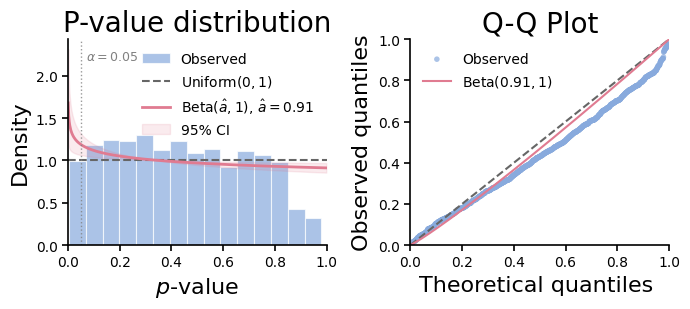

In [20]:
plotFig(boot_hyper_pvals,'Hyper_boot.pdf')

Beta(a, 1) posterior: a = 0.364 (95% CI: [0.342, 0.387])
Conservative (a > 1): False
Type I error at α=0.05: 371/1000 = 0.371
Clopper-Pearson 97.5% upper bound: 0.402


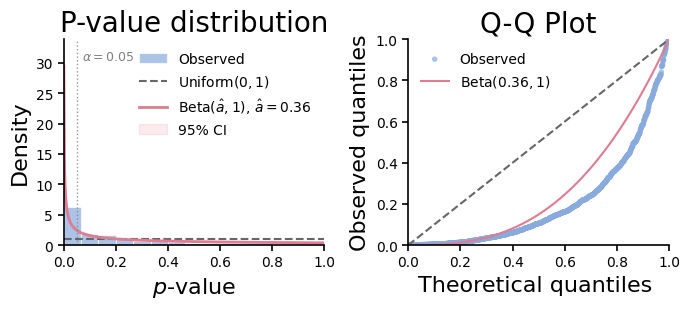

In [21]:
plotFig(lmr_lap_pvals,'Laplace_lmer.pdf')

Beta(a, 1) posterior: a = 0.479 (95% CI: [0.450, 0.509])
Conservative (a > 1): False
Type I error at α=0.05: 193/1000 = 0.193
Clopper-Pearson 97.5% upper bound: 0.219


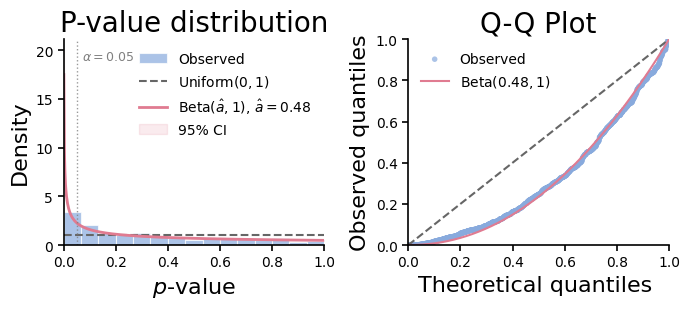

In [22]:
plotFig(lmr_gaussian_pvals,'Gauss_lmer.pdf')

Beta(a, 1) posterior: a = 0.644 (95% CI: [0.605, 0.685])
Conservative (a > 1): False
Type I error at α=0.05: 107/1000 = 0.107
Clopper-Pearson 97.5% upper bound: 0.128


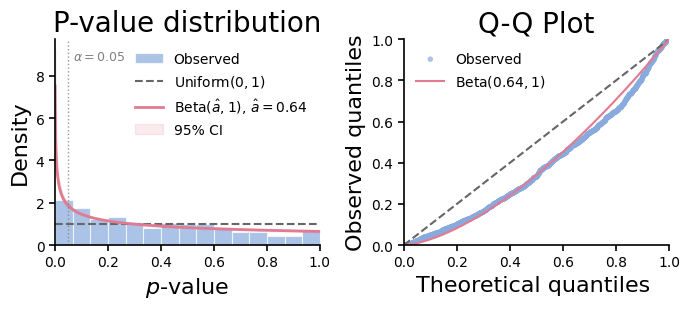

In [23]:
plotFig(lmr_gennorm_pvals,'Gennorm_lmer.pdf')

Beta(a, 1) posterior: a = 18.531 (95% CI: [17.401, 19.697])
Conservative (a > 1): True
Type I error at α=0.05: 1/1000 = 0.001
Clopper-Pearson 97.5% upper bound: 0.006


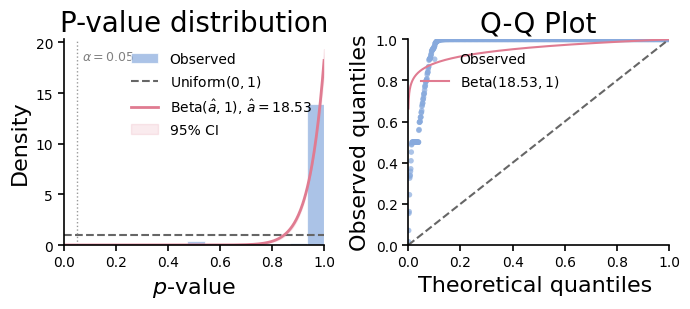

In [24]:
plotFig(lmr_hyper_pvals,'Hyper_lmer.pdf')

Beta(a, 1) posterior: a = 0.710 (95% CI: [0.667, 0.755])
Conservative (a > 1): False
Type I error at α=0.05: 89/1000 = 0.089
Clopper-Pearson 97.5% upper bound: 0.108


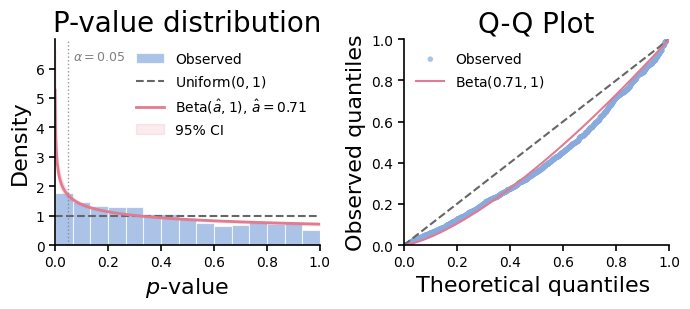

In [25]:
plotFig(lmr_student_pvals,'Student_lmer.pdf')